## Importing Dependencies

In [2]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Loading Constrained Realizations Into Dataframe

In [6]:
filename = "./constrainedMilkyWay.hdf5"
output = "Output1"

with h5py.File(filename, "r") as f:
    node_path = f"Outputs/{output}/nodeData"

    data = {}
    for key in f[node_path].keys():
        data[key] = f[node_path][key][:]
    
    out_path = f"Outputs/{output}"
    tree_start = f[f"{out_path}/mergerTreeStartIndex"][:]
    tree_count = f[f"{out_path}/mergerTreeCount"][:]
    tree_index = f[f"{out_path}/mergerTreeIndex"][:]

constrained_df = pd.DataFrame(data)

# Add tree IDs

constrained_df["tree_id"] = -1
for i, start in enumerate(tree_start):
    count = tree_count[i]
    constrained_df.loc[start:start + count - 1, "tree_id"] = tree_index[i]

constrained_df["absolute_distance"] = np.sqrt(constrained_df["satellitePositionX"]**2 + constrained_df["satellitePositionY"]**2 + constrained_df["satellitePositionZ"]**2)

print(constrained_df.describe())
print(constrained_df.head())
print(constrained_df.columns)
print(constrained_df.shape)
print(constrained_df["tree_id"].value_counts())

          basicMass  basicTimeLastIsolated  darkMatterProfileScale  \
count  1.329000e+04           13290.000000            13290.000000   
mean   1.282527e+10               6.811599                0.001940   
std    8.853659e+10               3.756728                0.002243   
min    1.005980e+08               0.362212                0.000219   
25%    3.518009e+08               3.664598                0.001016   
50%    7.694480e+08               6.354067                0.001396   
75%    2.224783e+09               9.853158                0.002069   
max    1.000000e+12              13.800484                0.051011   

       mergerTreeIndex     nodeIndex  nodeIsIsolated  nodeLabelIsLMCSubhalo  \
count     13290.000000  13290.000000    13290.000000           13290.000000   
mean         50.665388   4081.124906        0.007524               0.075320   
std          28.951342   4746.970401        0.086420               0.263917   
min           1.000000      1.000000        0.000000 

## Loading Unconstrained Realizations Into Dataframe

In [7]:
filename = "./unconstrainedMilkyWay.hdf5"
output = "Output1"

with h5py.File(filename, "r") as f:
    node_path = f"Outputs/{output}/nodeData"

    data = {}
    for key in f[node_path].keys():
        data[key] = f[node_path][key][:]
    
    out_path = f"Outputs/{output}"
    tree_start = f[f"{out_path}/mergerTreeStartIndex"][:]
    tree_count = f[f"{out_path}/mergerTreeCount"][:]
    tree_index = f[f"{out_path}/mergerTreeIndex"][:]

unconstrained_df = pd.DataFrame(data)

# Add tree IDs

unconstrained_df["tree_id"] = -1
for i, start in enumerate(tree_start):
    count = tree_count[i]
    unconstrained_df.loc[start:start + count - 1, "tree_id"] = tree_index[i]

print(unconstrained_df.describe())
print(unconstrained_df.columns)


          basicMass  basicTimeLastIsolated  darkMatterProfileScale  \
count  1.309900e+04           13099.000000            13099.000000   
mean   1.222750e+10               6.622552                0.001867   
std    8.894747e+10               3.758133                0.001881   
min    1.000875e+08               0.309911                0.000170   
25%    3.483565e+08               3.421227                0.001024   
50%    7.710992e+08               6.146548                0.001395   
75%    2.276966e+09               9.545182                0.002047   
max    1.000000e+12              13.800484                0.052459   

       mergerTreeIndex     nodeIndex  nodeIsIsolated  nodeSubsamplingWeight  \
count     13099.000000  13099.000000    13099.000000                13099.0   
mean         51.036186   3462.282006        0.007634                    1.0   
std          28.952640   4470.280935        0.087043                    0.0   
min           1.000000      1.000000        0.000000 

## Finding SMC Candidates In Constrained Data

In [8]:
min_smc_mass = 5.0e9
max_smc_mass = 8.0e9

smc_candidate_mask = (
    (constrained_df["nodeLabelWasLMCSubhalo"] == 1) &
    (constrained_df["basicMass"] > min_smc_mass) &
    (constrained_df["basicMass"] < max_smc_mass)
)

selected = constrained_df[smc_candidate_mask]
selected_ids = selected["tree_id"].tolist()
unique_selected_ids = set(selected_ids)
tree_id_with_multiple_candidates = selected["tree_id"].value_counts()
trees_with_multiple_candidates = tree_id_with_multiple_candidates[tree_id_with_multiple_candidates > 1].index.tolist()
trees_with_single_candidate = tree_id_with_multiple_candidates[tree_id_with_multiple_candidates == 1].index.tolist()

print(selected.columns)
print("Selected tree IDs:", selected_ids)
print("Trees with multiple candidates:", trees_with_multiple_candidates)
print("Trees with single candidate:", trees_with_single_candidate)
print("Number selected:", len(selected))
print("Number of unique tree IDs:", len(unique_selected_ids))
print("Number of trees with multiple candidates:", len(trees_with_multiple_candidates))
print("Number of trees with single candidate:", len(trees_with_single_candidate))


Index(['basicMass', 'basicTimeLastIsolated', 'darkMatterProfileScale',
       'mergerTreeIndex', 'nodeIndex', 'nodeIsIsolated',
       'nodeLabelIsLMCSubhalo', 'nodeLabelLMC', 'nodeLabelWasLMCSubhalo',
       'nodeSubsamplingWeight', 'parentIndex', 'satelliteBoundMass',
       'satelliteIndex', 'satellitePositionX', 'satellitePositionY',
       'satellitePositionZ', 'satelliteTidalHeatingNormalized',
       'satelliteVelocityX', 'satelliteVelocityY', 'satelliteVelocityZ',
       'siblingIndex', 'spinAngularMomentum', 'spinAngularMomentumVectorX',
       'spinAngularMomentumVectorY', 'spinAngularMomentumVectorZ', 'tree_id',
       'absolute_distance'],
      dtype='object')
Selected tree IDs: [97, 97, 74, 74, 74, 78, 95, 81, 81, 81, 92, 86, 90, 80, 84, 79, 2, 2, 82, 89, 96, 53, 68, 54, 57, 57, 59, 71, 76, 75, 75, 62, 63, 63, 66, 72, 51, 31, 32, 48, 22, 22, 52, 39, 39, 7, 30, 24, 19, 19, 36, 13, 13, 13, 8, 15, 28, 11, 10, 21, 17, 18, 18, 4, 4, 4]
Trees with multiple candidates: [74, 81, 

## SMC Candidates of trees with Multiple Candidates

In [9]:
special_smc_candidate_mask = (
    (constrained_df["tree_id"].isin(trees_with_multiple_candidates)) &
    (constrained_df["nodeLabelWasLMCSubhalo"] == 1) &
    (constrained_df["basicMass"] > min_smc_mass) &
    (constrained_df["basicMass"] < max_smc_mass)
)

special_candidates = constrained_df[special_smc_candidate_mask]
print("Number of special candidates:", len(special_candidates))

Number of special candidates: 30


## SMC Candidates from trees with only one SMC

In [10]:
regular_candidate_mask = (
    (constrained_df["tree_id"].isin(trees_with_single_candidate)) &
    (constrained_df["nodeLabelWasLMCSubhalo"] == 1) &
    (constrained_df["basicMass"] > min_smc_mass) &
    (constrained_df["basicMass"] < max_smc_mass)
)

regular_candidates = constrained_df[regular_candidate_mask]
print("Number of unique candidates:", len(regular_candidates))


Number of unique candidates: 36


## Histograms of Infall times of Regular Candidates vs Special Candidates

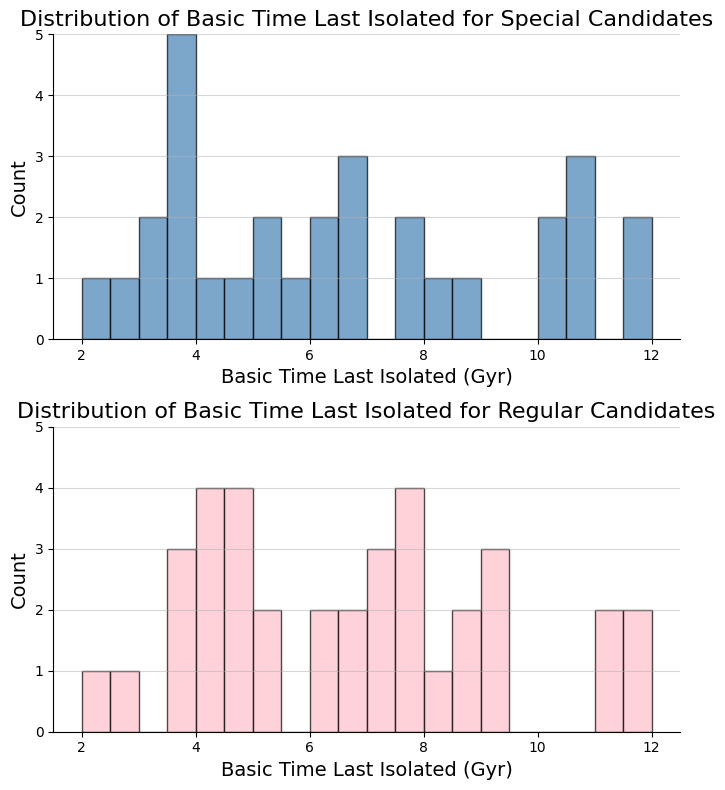

In [11]:
fig, ax = plt.subplots(2, 1, figsize = (7, 8))
bins = np.arange(2, 12.5, 0.5)

ax[0].hist(special_candidates["basicTimeLastIsolated"], bins=bins, color = "steelblue", edgecolor='black', alpha=0.7)
ax[0].set_title("Distribution of Basic Time Last Isolated for Special Candidates", fontsize=16)
ax[0].set_xlabel("Basic Time Last Isolated (Gyr)", fontsize=14)
ax[0].set_ylabel("Count", fontsize=14)
ax[0].set_ymargin(1)
ax[0].set_ylim(0, 5)
ax[0].grid(axis='y', alpha=0.5)

ax[1].hist(regular_candidates["basicTimeLastIsolated"], bins=bins, color = "pink", edgecolor='black', alpha=0.7)
ax[1].set_title("Distribution of Basic Time Last Isolated for Regular Candidates", fontsize=16)
ax[1].set_xlabel("Basic Time Last Isolated (Gyr)", fontsize=14)
ax[1].set_ylabel("Count", fontsize=14)
ax[1].set_ymargin(1)
ax[1].set_ylim(0, 5)
ax[1].grid(axis='y', alpha=0.5)

for axis in ax:
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()



# Mass Function

## Cummulative Mass Function

In [14]:
def cum_mass(m_sub):
    n = 100
    m_sub = np.array(m_sub)
    sorted_masses = np.sort(m_sub)

    idx = np.searchsorted(sorted_masses, sorted_masses, side="right")
    N = (len(sorted_masses) - idx)/n
    return sorted_masses, N


## Generate X and Y From Constrained

In [19]:
constrained_m_sub = constrained_df["basicMass"].to_list()
constrained_x, constrained_y = cum_mass(constrained_m_sub)
print(constrained_x)
print(constrained_y)

[1.00598022e+08 1.00743899e+08 1.01154660e+08 ... 1.00000000e+12
 1.00000000e+12 1.00000000e+12]
[132.89 132.88 132.87 ...   0.     0.     0.  ]


## Generate X and Y From Unconstrained

In [21]:
unconstrained_m_sub = unconstrained_df["basicMass"].to_list()
unconstrained_x, unconstrained_y = cum_mass(unconstrained_m_sub)
print(unconstrained_x)
print(unconstrained_y)

[1.00087518e+08 1.00785212e+08 1.01749338e+08 ... 1.00000000e+12
 1.00000000e+12 1.00000000e+12]
[130.98 130.97 130.96 ...   0.     0.     0.  ]


## Make Mass Function Plot

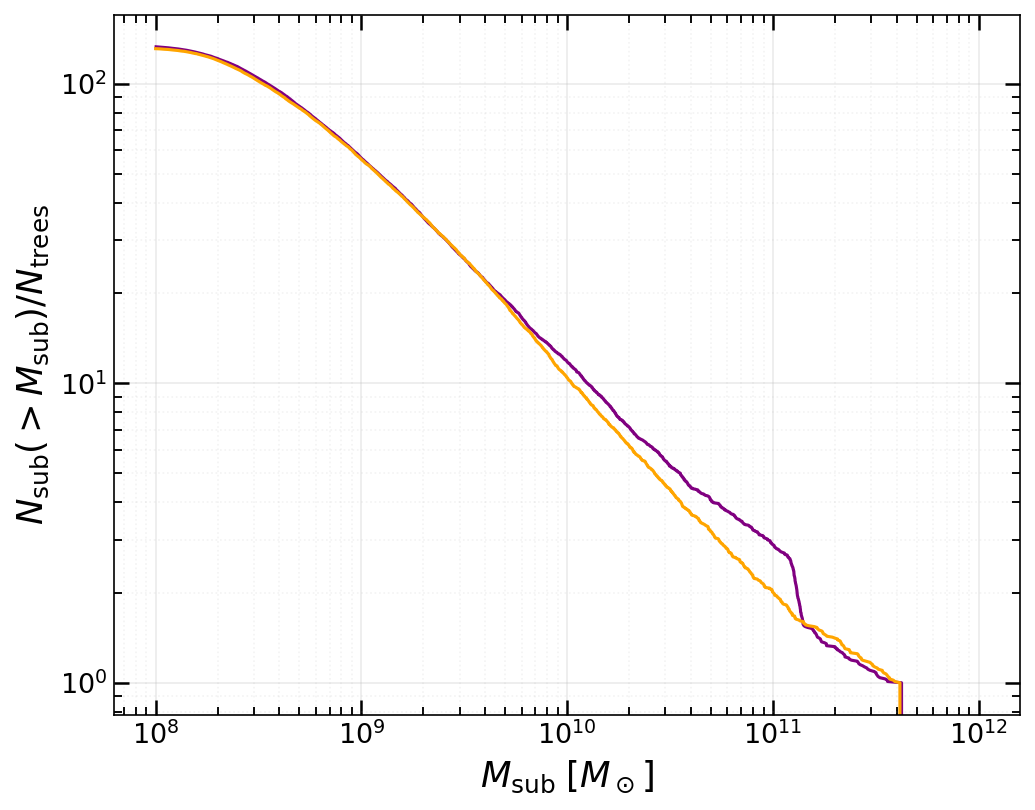

In [25]:
fig, ax = plt.subplots(figsize= (7, 5.5), dpi= 150)

ax.plot(constrained_x, constrained_y, color= "purple")
ax.plot(unconstrained_x, unconstrained_y, color= "orange")
ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"$M_{\rm sub}\;[M_\odot]$", fontsize=17)
ax.set_ylabel(r"$N_{\rm sub}(>M_{\rm sub})/ N_{\rm trees}$", fontsize=17)

ax.tick_params(axis="both", which="major", labelsize=13, direction="in", length=7, width=1.2)
ax.tick_params(axis="both", which="minor", direction="in", length=4, width=0.9)
ax.tick_params(top=True, right=True, which="both")

ax.grid(True, which="major", linestyle="-", alpha=0.25)
ax.grid(True, which="minor", linestyle=":", alpha=0.15)

fig.tight_layout()
plt.show()


## SMCs Still Associated with their Subhalos

In [ ]:
bound_smcs = selected[
    (selected["nodeLabelIsLMCSubhalo"] == 1)
]
regular_bound_smcs = regular_candidates[
    (regular_candidates["nodeLabelIsLMCSubhalo"] == 1)
]
special_bound_smcs = special_candidates[
    (special_candidates["nodeLabelIsLMCSubhalo"] == 1)
]
print (bound_smcs["tree_id"].to_list())
print (regular_bound_smcs["tree_id"].to_list())
print (special_bound_smcs["tree_id"].to_list())
print("Number of regular bound SMC candidates:", len(regular_bound_smcs))
print("Number of special bound SMC candidates:", len(special_bound_smcs))
print("Number of bound SMC candidates:", len(bound_smcs))

[97, 97, 74, 74, 74, 95, 81, 81, 92, 90, 2, 96, 53, 68, 57, 59, 76, 75, 63, 66, 51, 31, 32, 48, 22, 39, 7, 30, 24, 19, 19, 36, 13, 13, 13, 8, 15, 28, 11, 21, 17, 18, 4, 4]
[95, 92, 90, 96, 53, 68, 59, 76, 66, 51, 31, 32, 48, 7, 30, 24, 36, 8, 15, 28, 11, 21, 17]
[97, 97, 74, 74, 74, 81, 81, 2, 57, 75, 63, 22, 39, 19, 19, 13, 13, 13, 18, 4, 4]
Number of regular bound SMC candidates: 23
Number of special bound SMC candidates: 21
Number of bound SMC candidates: 44


## Including Distance in the definition of an SMC

In [ ]:
min_distance = 50.0
max_distance = 100.0

distance_mask = (
    (selected["absolute_distance"] > min_distance) &
    (selected["absolute_distance"] < max_distance)
)

print(selected["absolute_distance"].describe())
print(selected["satellitePositionX"].describe())
print(selected["satellitePositionY"].describe())
print(selected["satellitePositionZ"].describe())

new_smc_cands = selected[distance_mask]

print(new_smc_cands.describe())

count    66.000000
mean      0.138681
std       0.183274
min       0.020816
25%       0.063976
50%       0.091825
75%       0.151530
max       1.451600
Name: absolute_distance, dtype: float64
count    66.000000
mean     -0.018543
std       0.143224
min      -0.954822
25%      -0.049404
50%      -0.009866
75%       0.042131
max       0.258812
Name: satellitePositionX, dtype: float64
count    66.000000
mean      0.016847
std       0.133488
min      -0.268409
25%      -0.039298
50%      -0.003508
75%       0.039996
max       0.827304
Name: satellitePositionY, dtype: float64
count    66.000000
mean     -0.010968
std       0.118432
min      -0.714862
25%      -0.030586
50%       0.000584
75%       0.038548
max       0.237071
Name: satellitePositionZ, dtype: float64
       basicMass  basicTimeLastIsolated  darkMatterProfileScale  \
count        0.0                    0.0                     0.0   
mean         NaN                    NaN                     NaN   
std          NaN            